In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("../Data/Dataset 1_EV charging reports.csv", sep=";")


df.shape
df.columns
df.info()
df.head()


<class 'pandas.DataFrame'>
RangeIndex: 6878 entries, 0 to 6877
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   session_ID         6878 non-null   int64  
 1   Garage_ID          6878 non-null   str    
 2   User_ID            6878 non-null   str    
 3   User_type          6878 non-null   str    
 4   Shared_ID          1412 non-null   str    
 5   Start_plugin       6878 non-null   str    
 6   Start_plugin_hour  6878 non-null   int64  
 7   End_plugout        6844 non-null   str    
 8   End_plugout_hour   6844 non-null   float64
 9   El_kWh             6878 non-null   str    
 10  Duration_hours     6844 non-null   str    
 11  month_plugin       6878 non-null   str    
 12  weekdays_plugin    6878 non-null   str    
 13  Plugin_category    6878 non-null   str    
 14  Duration_category  6844 non-null   str    
dtypes: float64(1), int64(2), str(12)
memory usage: 806.1 KB


,session_ID,Garage_ID,User_ID,User_type,Shared_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,Duration_hours,month_plugin,weekdays_plugin,Plugin_category,Duration_category
0,1,AdO3,AdO3-4,Private,NaN,21.12.2018 10:20,10,21.12.2018 10:23,10.0,"0,3","0,05",Dec,Friday,late morning (9-12),Less than 3 hours
1,2,AdO3,AdO3-4,Private,NaN,21.12.2018 10:24,10,21.12.2018 10:32,10.0,"0,87","0,136666667",Dec,Friday,late morning (9-12),Less than 3 hours
2,3,AdO3,AdO3-4,Private,NaN,21.12.2018 11:33,11,21.12.2018 19:46,19.0,"29,87","8,216388889",Dec,Friday,late morning (9-12),Between 6 and 9 hours
3,4,AdO3,AdO3-2,Private,NaN,22.12.2018 16:15,16,23.12.2018 16:40,16.0,"15,56","24,41972222",Dec,Saturday,late afternoon (15-18),More than 18 hours
4,5,AdO3,AdO3-2,Private,NaN,24.12.2018 22:03,22,24.12.2018 23:02,23.0,"3,62","0,970555556",Dec,Monday,late evening (21-midnight),Less than 3 hours


In [11]:
df.isnull().sum()
df["Shared_ID"].value_counts(dropna=False)
df["User_type"].value_counts()



User_type
Private    5466
Shared     1412
Name: count, dtype: int64

In [12]:
df.duplicated().sum()

np.int64(0)

In [22]:
df.dtypes

pd.to_numeric(
    df["El_kWh"].str.replace(",", "."),
    errors="coerce"
).isna().sum()




np.int64(0)

In [24]:
df["Duration_hours"].head(10)
pd.to_numeric(
    df["Duration_hours"].str.replace(",", "."),
    errors="coerce"
).isna().sum()
df[df["Duration_hours"].isna()]
df_duration = df.dropna(subset = ["Duration_hours"])

In [34]:
# df["El_kWh"] = pd.to_numeric(
#     df["El_kWh"].str.replace(",", "."),
#     errors="coerce"
# )
# df["Duration_hours"] = pd.to_numeric(
#     df["Duration_hours"].str.replace(",", "."),
#     errors = "coerce"
# )
df.dtypes

session_ID             int64
Garage_ID                str
User_ID                  str
User_type                str
Shared_ID                str
Start_plugin             str
Start_plugin_hour      int64
End_plugout              str
End_plugout_hour     float64
El_kWh               float64
Duration_hours       float64
month_plugin             str
weekdays_plugin          str
Plugin_category          str
Duration_category        str
dtype: object

In [36]:
df["Start_plugin"] = pd.to_datetime(
    df["Start_plugin"], dayfirst=True
)
df["End_plugout"] = pd.to_datetime(
    df["End_plugout"],
    dayfirst= True
)

In [37]:
df.dtypes

session_ID                    int64
Garage_ID                       str
User_ID                         str
User_type                       str
Shared_ID                       str
Start_plugin         datetime64[us]
Start_plugin_hour             int64
End_plugout          datetime64[us]
End_plugout_hour            float64
El_kWh                      float64
Duration_hours              float64
month_plugin                    str
weekdays_plugin                 str
Plugin_category                 str
Duration_category               str
dtype: object

In [43]:
df["End_plugout"].head()
df.describe()

,session_ID,Start_plugin,Start_plugin_hour,End_plugout,End_plugout_hour,El_kWh,Duration_hours
count,6878.000000,6878,6878.000000,6844,6844.000000,6878.000000,6844.000000
mean,3439.500000,2019-10-01 11:38:00.218086,16.325240,2019-10-01 13:22:09.827586,12.546902,12.720744,11.504440
min,1.000000,2018-12-21 10:20:00,0.000000,2018-12-21 10:23:00,0.000000,0.010000,0.003333
25%,1720.250000,2019-08-04 21:32:15,15.000000,2019-08-04 18:50:30,7.000000,5.200000,2.789028
50%,3439.500000,2019-11-02 17:53:00,17.000000,2019-11-02 17:05:00,12.000000,9.050000,10.026250
75%,5158.750000,2019-12-19 06:15:30,19.000000,2019-12-19 07:25:30,17.000000,16.090000,15.221181
max,6878.000000,2020-01-31 20:42:00,23.000000,2020-01-31 23:53:00,23.000000,80.860000,255.029444
std,1985.651908,NaN,4.363108,NaN,5.256756,11.787938,14.148168


Text(0.5, 1.0, 'Distribution of EV Charging Energy')

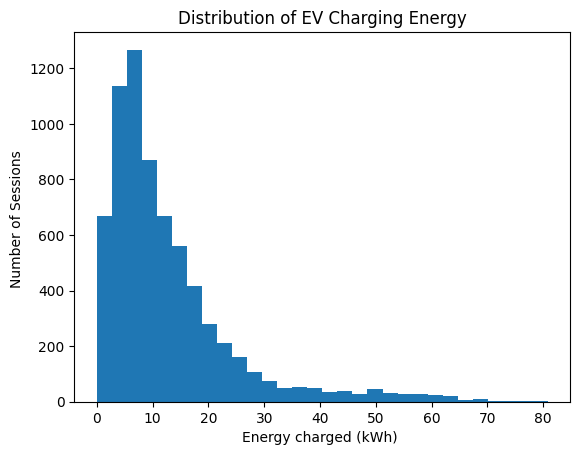

In [45]:
df["El_kWh"].plot(kind= "hist", bins = 30)
plt.xlabel("Energy charged (kWh) ")
plt.ylabel("Number of Sessions ")
plt.title("Distribution of EV Charging Energy")

In [ ]:
df.groupby("User_type")["El_kWh"].agg(["count", "mean", "median"])
# we can see that shared charging sessions uses more energy than private


,count,mean,median
User_type,,,
Private,5466,11.202226,8.210
Shared,1412,18.599086,14.705


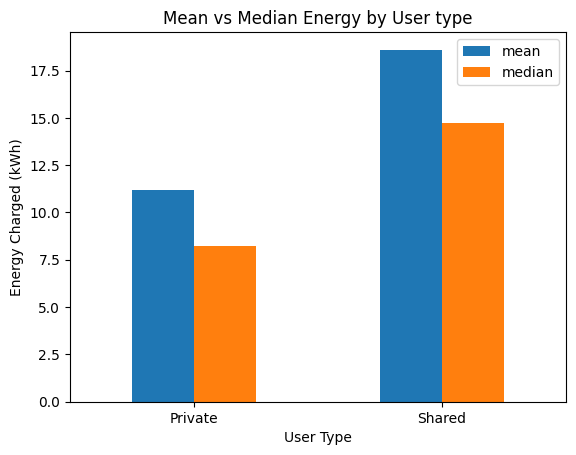

In [51]:
comparison = df.groupby("User_type")["El_kWh"].agg(["mean", "median"])
comparison.plot(kind="bar")
plt.xlabel("User Type")
plt.ylabel("Energy Charged (kWh)")
plt.title("Mean vs Median Energy by User type")
plt.xticks(rotation=0)
plt.show()

In [ ]:
df.groupby("User_type")["Duration_hours"].agg(["mean", "median"])
# here we can see that private user are taking longer charging sessions


,mean,median
User_type,,
Private,12.784593,11.247500
Shared,6.535401,3.999306


In [54]:
df["Charging_Power_kW"] = df["El_kWh"]/ df["Duration_hours"]
df[["El_kWh", "Duration_hours", "Charging_Power_kW"]].head(10)

,El_kWh,Duration_hours,Charging_Power_kW
0,0.30,0.050000,6.000000
1,0.87,0.136667,6.365854
2,29.87,8.216389,3.635417
3,15.56,24.419722,0.637190
4,3.62,0.970556,3.729823
5,16.14,18.077778,0.892809
6,10.33,21.720833,0.475580
7,27.66,6.188056,4.469902
8,8.83,2.371111,3.723993
9,8.58,4.856111,1.766846


In [ ]:
df.groupby("User_type")["Charging_Power_kW"].agg(["mean", "median"])
# Shared sessions tend to charge more energy in less time, which is consistent with their substantially higher average charging power.

,mean,median
User_type,,
Private,1.760431,1.140562
Shared,3.850068,3.561159


In [56]:
Hourly_Session = df["Start_plugin_hour"].value_counts().sort_index()
Hourly_Session

Start_plugin_hour
0     102
1      40
2      25
3      17
4       7
5       9
6      19
7      79
8      81
9      66
10    116
11    173
12    202
13    294
14    408
15    787
16    966
17    608
18    584
19    676
20    583
21    463
22    374
23    199
Name: count, dtype: int64

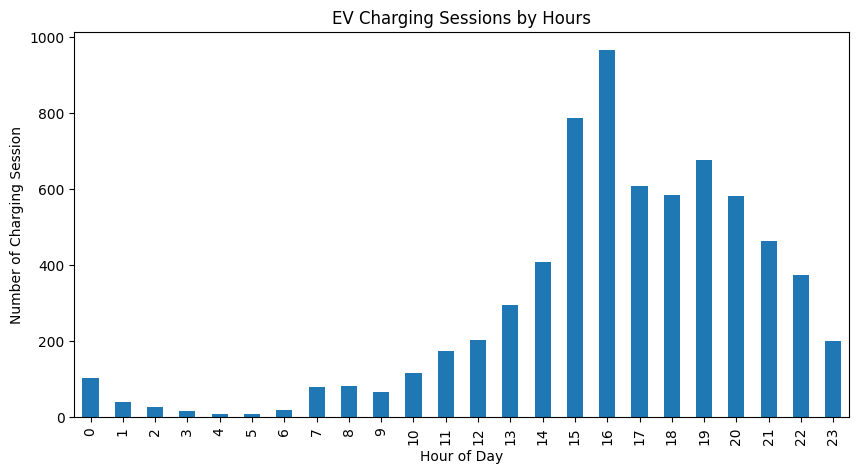

In [57]:
Hourly_Session.plot(kind= 'bar', figsize = (10,5))
plt.xlabel("Hour of Day")
plt.ylabel("Number of Charging Session")
plt.title("EV Charging Sessions by Hours")

plt.show()

In [58]:
Weekdays_Session = df["weekdays_plugin"].value_counts()
Weekdays_Session

weekdays_plugin
Thursday     1072
Wednesday    1039
Friday       1034
Monday        981
Sunday        955
Tuesday       943
Saturday      854
Name: count, dtype: int64

In [60]:
df.groupby("weekdays_plugin")["El_kWh"].agg(["count", "mean", "median"])
# Thursday has the most charging sessions (1,072), but Sunday has a higher average energy per session (14.78 kWh vs 13.08 kWh on Thursday).

,count,mean,median
weekdays_plugin,,,
Friday,1034,11.918356,8.485
Monday,981,11.998614,8.890
Saturday,854,12.530164,8.460
Sunday,955,14.779414,10.470
Thursday,1072,13.078284,9.240
Tuesday,943,12.315323,9.140
Wednesday,1039,12.464572,9.040


In [ ]:
df.groupby("weekdays_plugin")["Duration_hours"].agg(["count", "mean", "median"])
# Thursday has higher charging activity by session count, while Sunday sessions tend to involve more energy and longer charging durations.

,count,mean,median
weekdays_plugin,,,
Friday,1034,13.390919,9.959167
Monday,968,11.432806,9.812222
Saturday,853,13.914938,10.673056
Sunday,953,11.146042,10.558333
Thursday,1063,10.450388,9.613056
Tuesday,936,10.375343,10.211111
Wednesday,1037,10.136469,9.935556


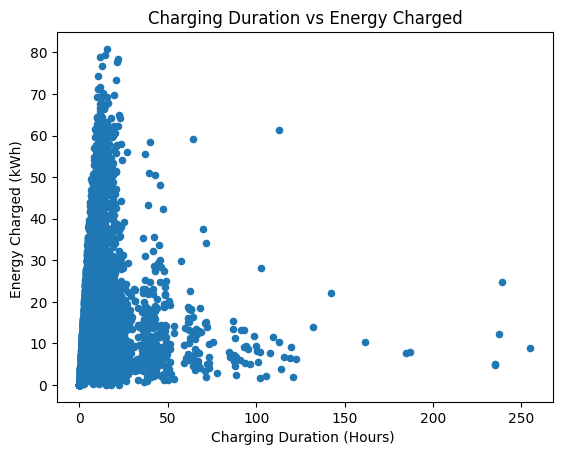

In [62]:
df.plot(x= "Duration_hours", y= "El_kWh", kind= "scatter")
plt.xlabel("Charging Duration (Hours) ")
plt.ylabel("Energy Charged (kWh) ")
plt.title("Charging Duration vs Energy Charged")

plt.show()

In [63]:
df[["Duration_hours", "El_kWh"]].corr()

,Duration_hours,El_kWh
Duration_hours,1.000000,0.105448
El_kWh,0.105448,1.000000


In [64]:
df["Charging_Power_kW"].describe()

count    6844.000000
mean        2.188495
std         1.911073
min         0.000559
25%         0.632675
50%         1.515267
75%         3.515889
max         7.776832
Name: Charging_Power_kW, dtype: float64

In [65]:
Garage_Session = df["Garage_ID"].value_counts()
Garage_Session

Garage_ID
Bl2      2243
AsO2      665
AdO1      586
UT9       421
AdO3      379
UT7       313
MS1       270
AsO10     253
NR1       224
SR2       221
MS22      187
UT15      170
UT1       166
AdA6      156
Ris       107
SR14      105
AsO8      104
AsO4      103
AdA1       97
AsO6       39
UT2        28
Bl7        19
MS11       14
SR4         8
Name: count, dtype: int64

In [66]:
garage_energy = df.groupby("Garage_ID")["El_kWh"].agg(["count", "sum", "mean"])

garage_energy.sort_values("sum", ascending=False)

,count,sum,mean
Garage_ID,,,
Bl2,2243,27046.92,12.058368
AsO2,665,10672.16,16.048361
AdO1,586,8372.83,14.288106
UT9,421,6789.82,16.127838
AdO3,379,5239.22,13.823799
SR14,105,3791.26,36.107238
SR2,221,3768.99,17.054253
AsO10,253,3428.27,13.550474
MS22,187,2651.19,14.177487


In [67]:
df[df["Garage_ID"] == "Bl7"][[
    "El_kWh",
    "Duration_hours",
    "Charging_Power_kW"
]].describe()

,El_kWh,Duration_hours,Charging_Power_kW
count,19.000000,19.000000,19.000000
mean,45.576842,12.683114,4.518383
std,19.572153,8.777486,1.687195
min,2.610000,0.386111,1.292480
25%,42.195000,9.887778,3.635601
50%,51.030000,11.722500,4.121412
75%,58.110000,13.892222,5.949745
max,63.300000,39.482222,6.994113


In [ ]:
garage_analysis = df.groupby("Garage_ID")["El_kWh"].agg(
    sessions="count",
    avg_energy="mean"
)

garage_analysis[garage_analysis["sessions"] >= 50].sort_values(
    "avg_energy",
    ascending=False
)
# Session volume ≠ charging intensity.


,sessions,avg_energy
Garage_ID,,
SR14,105,36.107238
SR2,221,17.054253
UT9,421,16.127838
AsO2,665,16.048361
AdO1,586,14.288106
MS22,187,14.177487
AdO3,379,13.823799
AsO10,253,13.550474
Bl2,2243,12.058368


In [69]:
df[df["Garage_ID"]== "SR14" ].groupby("User_type")["El_kWh"].agg(["count", "mean", "median"])

,count,mean,median
User_type,,,
Private,105,36.107238,38.11


In [ ]:
df[df["Garage_ID"]== "SR14"]["El_kWh"].describe()
# SR14 shows consistently high energy consumption per session compared with the other garages in our dataset.

count    105.000000
mean      36.107238
std       17.225699
min        0.110000
25%       24.000000
50%       38.110000
75%       48.870000
max       67.040000
Name: El_kWh, dtype: float64